In [97]:
import numpy as np
import matplotlib.pyplot as plt

N = 30
N_flap = 15
N_total = N + N_flap
h = 0.5
U_inf = 1.0

# Angle of the physical aircraft geometry
alpha_wing_deg = 5
alpha_wing = np.radians(alpha_wing_deg)
# Angle of the incoming wind
alpha_wind_deg = 0
alpha_wind = np.radians(alpha_wind_deg)
#flap angle
flap_angle_deg = -15
flap_deflection = np.radians(flap_angle_deg)

#create flat main airfoil
x_panel_flat = np.linspace(0 , 1 , N+1)
y_panel_flat = 0.1*x_panel_flat*(1 - x_panel_flat)

#creat flat flap
flap_chord = 0.4
x_flap_local = np.linspace(0, flap_chord, N_flap + 1)
y_flap_local = (0.06* x_flap_local* (1 - x_flap_local / flap_chord))

# Rotate the flap around its own leading edge using a rotation matrix
x_flap_def = (x_flap_local * np.cos(flap_deflection)) - (y_flap_local * np.sin(flap_deflection))
y_flap_def = (x_flap_local * np.sin(flap_deflection)) + (y_flap_local * np.cos(flap_deflection))

flap_shift_x = 0.9
flap_shift_y = -0.12
x_flap_assembled = x_flap_def + flap_shift_x
y_flap_assembled = y_flap_def + flap_shift_y

# We use negative alpha_wing to rotate the nose up geometrically
# Rotate Main Wing
x_panel = (x_panel_flat * np.cos(-alpha_wing)) - (y_panel_flat * np.sin(-alpha_wing))
y_panel = (x_panel_flat * np.sin(-alpha_wing)) + (y_panel_flat * np.cos(-alpha_wing))

# Rotate Assembled Flap (This swings it along with the main wing)
x_flap = (x_flap_assembled * np.cos(-alpha_wing)) - (y_flap_assembled * np.sin(-alpha_wing))
y_flap = (x_flap_assembled * np.sin(-alpha_wing)) + (y_flap_assembled * np.cos(-alpha_wing))

#ground clearanced
y_panel = y_panel + h
y_flap = y_flap + h


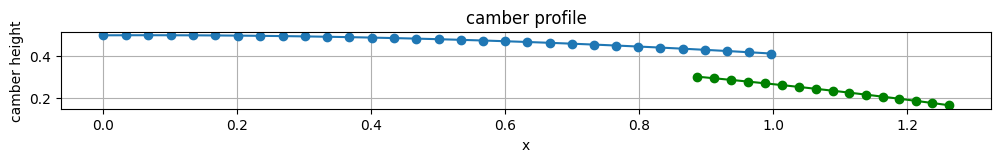

In [98]:
# plot the chamber surface
plt.figure(figsize=(12,1))
plt.plot(x_panel,y_panel, marker = 'o')
plt.plot(x_flap, y_flap, '-o',color = 'green')
plt.xlabel("x")
plt.ylabel("camber height")
plt.title("camber profile")
plt.grid(True)
plt.show()


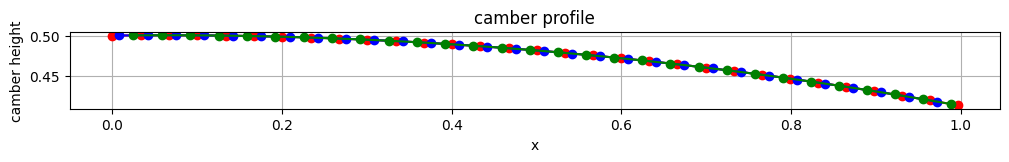

In [99]:
x_vortex = (1-0.25) * x_panel[:-1] + 0.25 * x_panel[1:]
x_collocation = (1-0.75) * x_panel[:-1] + 0.75 * x_panel[1:]
y_vortex = 0.75 * y_panel[:-1] + 0.25 * y_panel[1:]
y_collocation = 0.25 * y_panel[:-1] + 0.75 * y_panel[1:]

x_vortex_flap = 0.75 * x_flap[:-1] + 0.25 * x_flap[1:]
y_vortex_flap = 0.75 * y_flap[:-1] + 0.25 * y_flap[1:]
x_collocation_flap = 0.25 * x_flap[:-1] + 0.75 * x_flap[1:]
y_collocation_flap = 0.25 * y_flap[:-1] + 0.75 * y_flap[1:]

plt.figure(figsize =(12,1))
plt.plot(x_panel,y_panel, marker = 'o', color = 'red')
plt.plot(x_vortex,y_vortex, marker = 'o', color = 'blue')
plt.plot(x_collocation,y_collocation, marker = 'o', color = 'green')
plt.xlabel("x")
plt.ylabel("camber height")
plt.title("camber profile")
plt.grid(True)
plt.show()

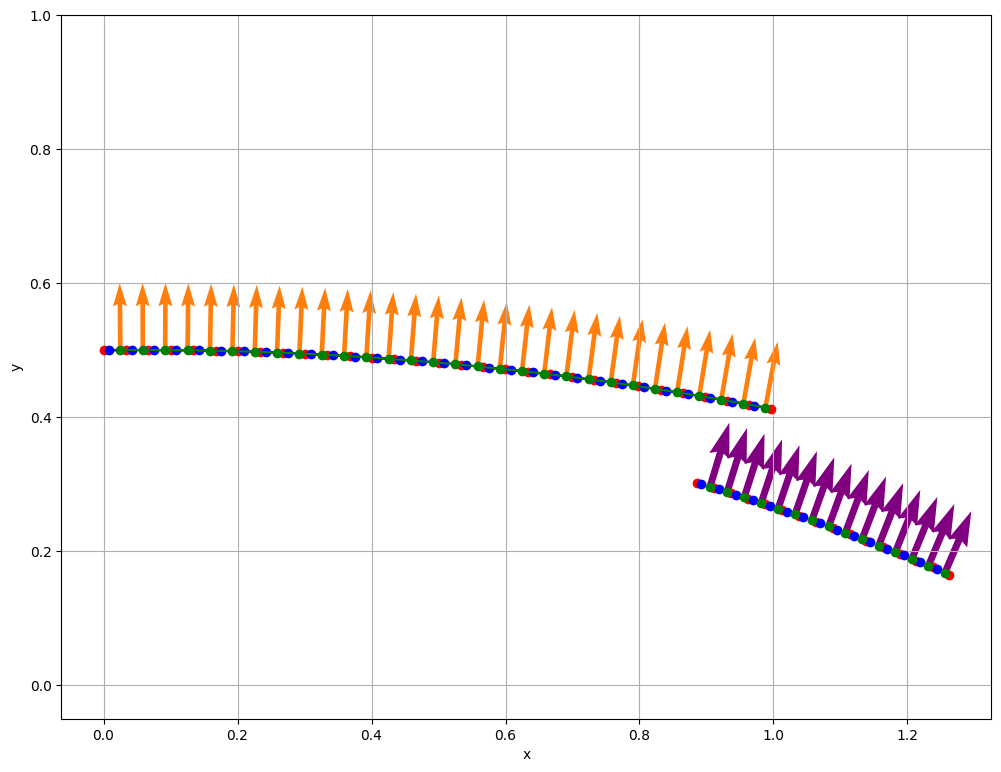

In [100]:
# creating panel normal
dx = np.zeros(N)
dy = np.zeros(N)
for i in range(N):
    dx[i] = x_panel[i+1] - x_panel[i]
    dy[i] = y_panel[i+1] - y_panel[i]
panel_length = np.sqrt(dx**2 + dy**2)
tx = dx / panel_length
ty = dy / panel_length
nx = -ty
ny = tx

dx_flap = np.zeros(N_flap)
dy_flap = np.zeros(N_flap)
for i in range(N_flap):

    dx_flap[i] = x_flap[i+1] - x_flap[i]

    dy_flap[i] = y_flap[i+1] - y_flap[i]

panel_length_flap = np.sqrt(
    dx_flap**2 + dy_flap**2
)

tx_flap = dx_flap / panel_length_flap
ty_flap = dy_flap / panel_length_flap

nx_flap = -ty_flap
ny_flap = tx_flap

fig, ax = plt.subplots(figsize = (12,10))
ax.plot(x_panel, y_panel, '-k')
ax.set_ylim(-0.05,1)
scale = 0.1
ax.plot(x_panel,y_panel, marker = 'o', color = 'red')
ax.plot(x_vortex,y_vortex, marker = 'o', color = 'blue')
ax.plot(x_collocation,y_collocation, marker = 'o', color = 'green')
ax.quiver(x_collocation,y_collocation, nx, ny, angles= 'xy', scale_units = 'xy', scale = 1/scale, color = 'C1', width = 0.005)
ax.set_aspect('equal', 'box')
ax.set_xlabel('x')
ax.set_ylabel('y')
#flap panel points
ax.plot(x_flap,y_flap,'or' )
# Flap vortex points
ax.plot(x_vortex_flap,y_vortex_flap,'ob')

# Flap collocation points
ax.plot(x_collocation_flap,y_collocation_flap,'og')

# Flap normals
ax.quiver(x_collocation_flap,y_collocation_flap,nx_flap,ny_flap,angles='xy',scale_units='xy',scale=1/scale,color='purple')
plt.grid(True)
plt.show()

#print(dx)
#print(dy)
#print(panel_length)

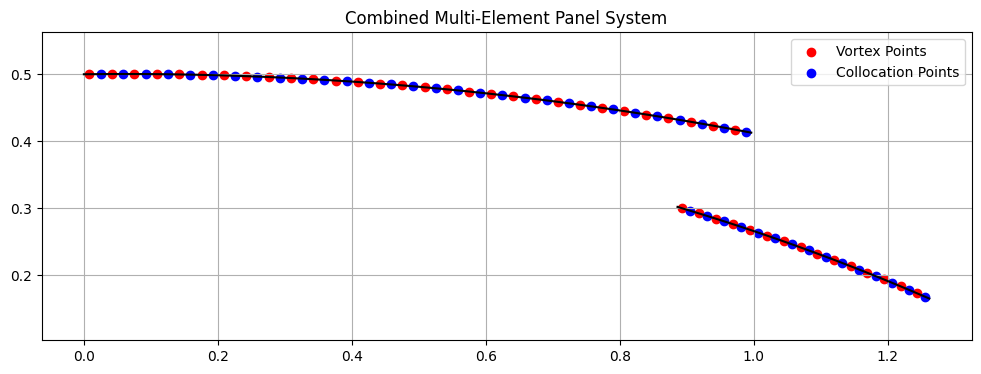

In [101]:
# combine main airfoil and flap arrays as a global combined system

# Vortex points
x_vortex_total = np.concatenate(
    (x_vortex, x_vortex_flap)
)

y_vortex_total = np.concatenate(
    (y_vortex, y_vortex_flap)
)

x_collocation_total = np.concatenate(
    (x_collocation, x_collocation_flap)
)

y_collocation_total = np.concatenate(
    (y_collocation, y_collocation_flap)
)

tx_total = np.concatenate(
    (tx, tx_flap)
)

ty_total = np.concatenate(
    (ty, ty_flap)
)

nx_total = np.concatenate(
    (nx, nx_flap)
)

ny_total = np.concatenate(
    (ny, ny_flap)
)

plt.figure(figsize=(12,4))
plt.plot(x_panel, y_panel, '-k')
plt.plot(x_flap, y_flap, '-k')
plt.scatter(x_vortex_total,y_vortex_total,color='red',label='Vortex Points')
plt.scatter(x_collocation_total,y_collocation_total,color='blue',label='Collocation Points')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title('Combined Multi-Element Panel System')

plt.show()

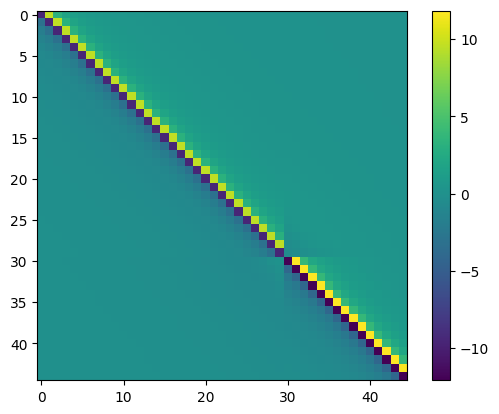

In [102]:
#work on building the influence matrix
A = np.zeros((N_total, N_total))

for i in range(N_total):

    for j in range(N_total):


        # REAL VORTEX


        delx = (
            x_collocation_total[i]
            -
            x_vortex_total[j]
        )

        dely = (
            y_collocation_total[i]
            -
            y_vortex_total[j]
        )

        r_squared = delx**2 + dely**2

        r_squared = max(r_squared, 1e-10)

        u = (
            1 / (2*np.pi)
        ) * (
            dely / r_squared
        )

        v = -(
            1 / (2*np.pi)
        ) * (
            delx / r_squared
        )


        # IMAGE VORTEX


        x_image = x_vortex_total[j]

        y_image = -y_vortex_total[j]

        delx_img = (
            x_collocation_total[i]
            -
            x_image
        )

        dely_img = (
            y_collocation_total[i]
            -
            y_image
        )

        r_squared_img = (
            delx_img**2 + dely_img**2
        )

        r_squared_img = max(
            r_squared_img,
            1e-10
        )

        u_img = -(
            1 / (2*np.pi)
        ) * (
            dely_img / r_squared_img
        )

        v_img = (
            1 / (2*np.pi)
        ) * (
            delx_img / r_squared_img
        )


        # TOTAL NORMAL VELOCITY


        A[i,j] = (
            (u + u_img) * nx_total[i]
            +
            (v + v_img) * ny_total[i]
        )

plt.imshow(A)
plt.colorbar()

In [103]:
#build free stream RHS


b = np.zeros(N_total)

for i in range(N_total):

    b[i] = -(
        U_inf * np.cos(alpha_wind) * nx_total[i]
        +
        U_inf * np.sin(alpha_wind) * ny_total[i]
    )


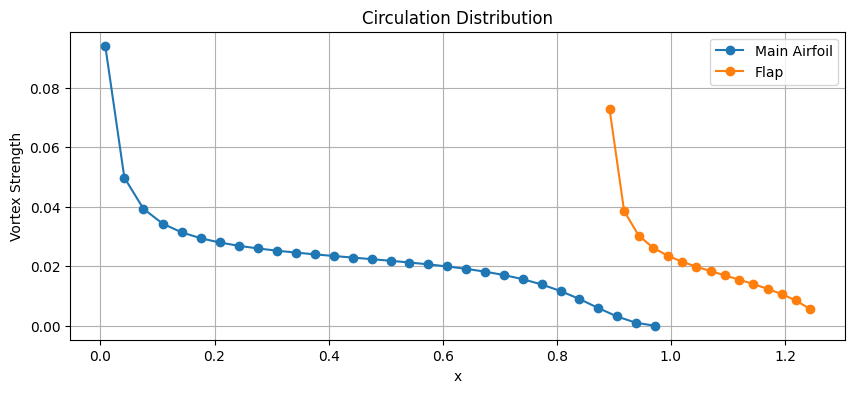

In [104]:
# solve for gamma
Gamma = np.linalg.solve(A,b)
Gamma_main = Gamma[:N]

Gamma_flap = Gamma[N:]

plt.figure(figsize=(10,4))

plt.plot(
    x_vortex,
    Gamma_main,
    '-o',
    label='Main Airfoil'
)

plt.plot(
    x_vortex_flap,
    Gamma_flap,
    '-o',
    label='Flap'
)

plt.xlabel('x')

plt.ylabel('Vortex Strength')

plt.title('Circulation Distribution')

plt.grid(True)

plt.legend()

plt.show()

In [105]:
Gamma_total = np.sum(Gamma)

CL = 2 * Gamma_total

print("Total circulation =", Gamma_total)

print("Lift coefficient CL =", CL)

Total circulation = 1.0341611193026878
Lift coefficient CL = 2.0683222386053757


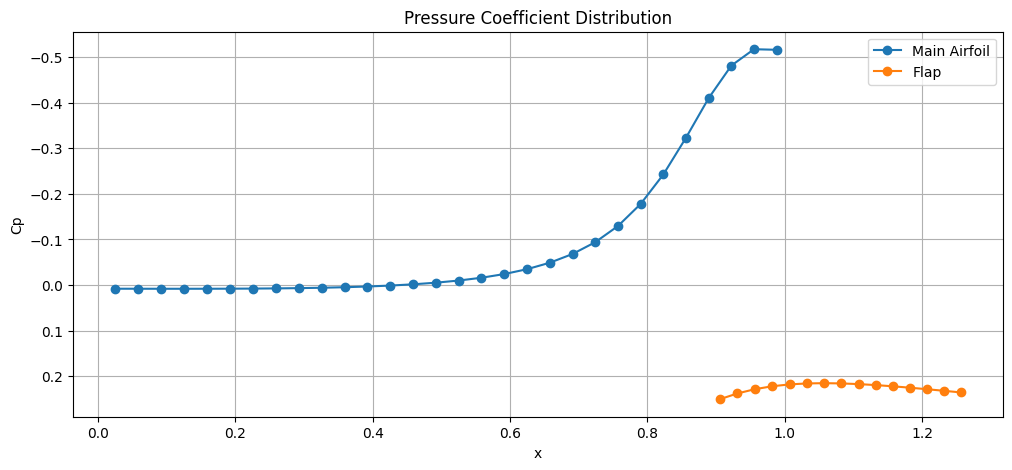

In [106]:

# TANGENTIAL VELOCITY


Vt = np.zeros(N_total)
Gamma_img = -Gamma[j]
for i in range(N_total):

    # Freestream tangential velocity
    Vt[i] = (
        U_inf * np.cos(alpha_wind) * tx_total[i]
        +
        U_inf * np.sin(alpha_wind) * ty_total[i]
    )

    # Add vortex contributions
    for j in range(N_total):


        # REAL VORTEX


        delx = (
            x_collocation_total[i]
            -
            x_vortex_total[j]
        )

        dely = (
            y_collocation_total[i]
            -
            y_vortex_total[j]
        )

        r_squared = delx**2 + dely**2

        r_squared = max(r_squared, 1e-10)

        u = (
            Gamma[j] / (2*np.pi)
        ) * (
            dely / r_squared
        )

        v = -(
            Gamma[j] / (2*np.pi)
        ) * (
            delx / r_squared
        )

        # IMAGE VORTEX

        x_image = x_vortex_total[j]

        y_image = -y_vortex_total[j]

        delx_img = (
            x_collocation_total[i]
            -
            x_image
        )

        dely_img = (
            y_collocation_total[i]
            -
            y_image
        )

        r_squared_img = (
            delx_img**2 + dely_img**2
        )

        r_squared_img = max(
            r_squared_img,
            1e-10
        )

        u_img = (
            Gamma_img / (2*np.pi)
        ) * (
            dely_img / r_squared_img
        )

        v_img = -(
            Gamma_img / (2*np.pi)
        ) * (
            delx_img / r_squared_img
        )


        # TOTAL TANGENTIAL VELOCITY


        Vt[i] += (
            (u + u_img) * tx_total[i]
            +
            (v + v_img) * ty_total[i]
        )

Cp = 1 - (Vt/U_inf)**2
Cp_main = Cp[:N]
Cp_flap = Cp[N:]


plt.figure(figsize=(12,5))

plt.plot(
    x_collocation,
    Cp_main,
    '-o',
    label='Main Airfoil'
)

plt.plot(
    x_collocation_flap,
    Cp_flap,
    '-o',
    label='Flap'
)

plt.gca().invert_yaxis()

plt.xlabel('x')

plt.ylabel('Cp')

plt.title('Pressure Coefficient Distribution')

plt.grid(True)

plt.legend()

plt.show()

In [107]:
X, Y = np.meshgrid(
    np.linspace(-0.3, 1.6, 220),
    np.linspace(0.02, 1, 220)
)


# INITIALIZE WITH FREESTREAM
U = U_inf * np.cos(alpha_wind) * np.ones_like(X)

V = U_inf * np.sin(alpha_wind) * np.ones_like(Y)


# ADD VORTEX CONTRIBUTIONS


for j in range(N_total):

    # REAL VORTEX


    delx = X - x_vortex_total[j]

    dely = Y - y_vortex_total[j]

    r_squared = delx**2 + dely**2

    r_squared[r_squared < 1e-10] = 1e-10

    u_induced = (
        Gamma[j] / (2*np.pi)
    ) * (
        dely / r_squared
    )

    v_induced = -(
        Gamma[j] / (2*np.pi)
    ) * (
        delx / r_squared
    )

    U += u_induced

    V += v_induced

    # IMAGE VORTEX

    x_image = x_vortex_total[j]

    y_image = -y_vortex_total[j]

    delx_img = X - x_image

    dely_img = Y - y_image

    r_squared_img = (
        delx_img**2 + dely_img**2
    )
    Gamma_img = -Gamma[j]
    r_squared_img[
        r_squared_img < 1e-10
    ] = 1e-10

    u_img = (
        Gamma_img / (2*np.pi)
    ) * (
        dely_img / r_squared_img
    )

    v_img = -(
        Gamma_img / (2*np.pi)
    ) * (
        delx_img / r_squared_img
    )

    U += u_img

    V += v_img

# VELOCITY MAGNITUDE


velocity_magnitude = np.sqrt(U**2 + V**2)





False
False


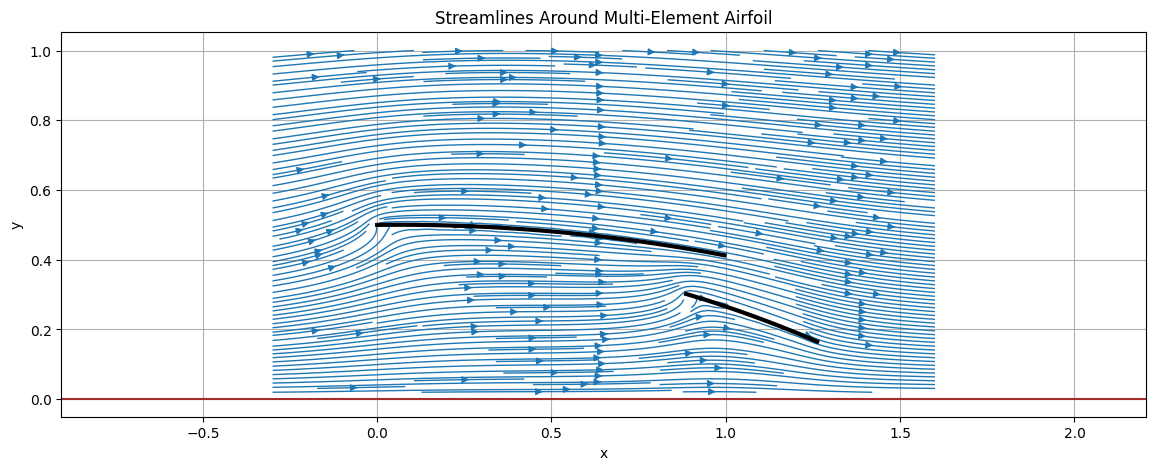

In [108]:


print(np.isnan(U).any())
print(np.isnan(V).any())
plt.figure(figsize=(14,5))
plt.streamplot(
    X,
    Y,
    U,
    V,

    density=3,
    linewidth=1
)

# Main airfoil
plt.plot(x_panel, y_panel, '-k', linewidth=3)

# Flap
plt.plot(x_flap, y_flap, '-k', linewidth=3)

# Ground
plt.axhline( y=0, color='brown')

plt.axis('equal')

plt.xlabel('x')

plt.ylabel('y')

plt.title(
    'Streamlines Around Multi-Element Airfoil'
)

plt.grid(True)

plt.show()

In [109]:
x_test = np.linspace(-0.2, 1.6, 200)

y_test = np.zeros_like(x_test)

V_wall = np.zeros_like(x_test)

for j in range(N_total):


    # REAL VORTEX

    delx = x_test - x_vortex_total[j]

    dely = y_test - y_vortex_total[j]

    r_squared = delx**2 + dely**2

    r_squared[r_squared < 1e-10] = 1e-10

    v_real = -(
        Gamma[j]/(2*np.pi)
    ) * (
        delx/r_squared
    )

    # IMAGE VORTEX


    x_image = x_vortex_total[j]

    y_image = -y_vortex_total[j]

    delx_img = x_test - x_image

    dely_img = y_test - y_image

    r_squared_img = delx_img**2 + dely_img**2

    r_squared_img[r_squared_img < 1e-10] = 1e-10

    Gamma_img = -Gamma[j]

    v_img = -(
        Gamma_img/(2*np.pi)
    ) * (
        delx_img/r_squared_img
    )

    V_wall += v_real + v_img

print(np.max(np.abs(V_wall))) #to know that at wall or ground there should be zero perpendicular velocity

0.0


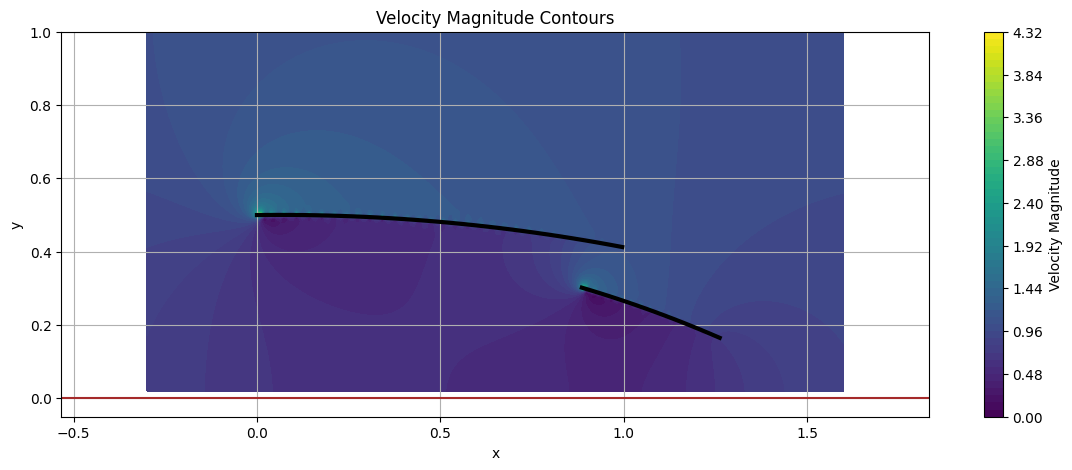

In [110]:
plt.figure(figsize=(14,5))

contour = plt.contourf(
    X,
    Y,
    velocity_magnitude,
    levels=60
)

plt.colorbar(
    contour,
    label='Velocity Magnitude'
)

# Main airfoil
plt.plot(
    x_panel,
    y_panel,
    '-k',
    linewidth=3
)

# Flap
plt.plot(
    x_flap,
    y_flap,
    '-k',
    linewidth=3
)

# Ground
plt.axhline(
    y=0,
    color='brown'
)

plt.axis('equal')

plt.xlabel('x')

plt.ylabel('y')

plt.title(
    'Velocity Magnitude Contours'
)

plt.grid(True)

plt.show()